In [ ]:
"""
UNIVERSAL FUNCTIONS vs AGGREGATE FUNCTIONS
> ufuncs perform an operation element-wise.
> Aggregation (reduction) functions take many elements and reduce them to one value (or one value per axis).
> Some reductions like np.sum(), np.min(), and np.max() are implemented as methods of ufuncs (for example, np.add.reduce() 
is essentially what np.sum() uses internally). However, functions like np.mean() and np.std() are not ufuncs.

NumPy Functions
│
├── Universal Functions (ufuncs)
│   ├── Arithmetic
│   │   ├── add()
│   │   ├── subtract()
│   │   ├── multiply()
│   │   ├── divide()
│   │   └── power()
│   │
│   ├── Trigonometric
│   ├── Exponential & Logarithmic
│   ├── Comparison
│   └── Logical
│
└── Aggregation (Reduction) Functions
    ├── sum()
    ├── min()
    ├── max()
    ├── mean()
    ├── std()
    ├── var()
    ├── prod()
    ├── any()
    └── all()
"""

In [4]:
import numpy as np

In [6]:
rng = np.random.default_rng()

In [9]:
x = rng.random(100)

In [19]:
%timeit np.sum(x)

6.84 μs ± 473 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [ ]:
# numpy functions are faster than the similar built in python functions

In [20]:
%timeit sum(x)

18.3 μs ± 2.39 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [ ]:
#NOTE: while similar, these functions aren't identical. More than 1 args are interpreted differently. np funcs can compute over multi dimensional arrays too

In [21]:
np.min(x)

np.float64(0.03131504552846387)

In [22]:
np.max(x)

np.float64(0.9720059416026267)

In [ ]:
#can use built in funcs of these numpy array objects too:

In [23]:
x.min()

np.float64(0.03131504552846387)

In [ ]:
"""
Multidimensional Aggregation using attribute 'axis':
- axis = 0 : 'collapse' the rows, i.e find aggregate value for each column 
- axis = 1 : 'collapse' the columns, i.e find aggregate value for each row 
"""

In [30]:
y = rng.integers(1,10, (3,4))
y

array([[7, 6, 5, 8],
       [1, 7, 6, 1],
       [4, 7, 7, 9]])

In [31]:
np.min(y, axis = 0)

array([1, 6, 5, 1])

In [32]:
np.max(y, axis = 1)

array([8, 7, 9])

In [ ]:
"""
NaN stands for Not a Number.
It is a special floating-point value used to represent missing or undefined data. 
Normally, if an array contains a NaN, many aggregation functions return NaN because they cannot compute a valid result.
Which is why Nan-safe versions of aggregate functions are needed. Examples include:

Function name	NaN-safe version	Description
np.sum	        np.nansum	        Compute sum of elements
np.prod	        np.nanprod	        Compute product of elements
np.mean	        np.nanmean	        Compute mean of elements
np.std	        np.nanstd	        Compute standard deviation
np.var	        np.nanvar	        Compute variance
np.min	        np.nanmin	        Find minimum value
np.max	        np.nanmax	        Find maximum value
np.argmin	    np.nanargmin	    Find index of minimum value
np.argmax	    np.nanargmax	    Find index of maximum value
np.median	    np.nanmedian	    Compute median of elements
np.percentile	np.nanpercentile	Compute rank-based statistics of elements
np.any	        N/A	Evaluate whether any elements are true
np.all	        N/A	Evaluate whether all elements are true

"""

In [36]:
z = [1, 2 ,3, np.nan, 7, 9]

In [38]:
np.min(z)

np.float64(nan)

In [39]:
np.nanmin(z)

np.float64(1.0)

In [ ]:
#EXAMPLE: USING AGGREGATE FUNCTIONS FOR SUMMARY STATISTICS

In [49]:
import pandas as pd
data = pd.read_csv('../data/president_heights.csv')
data.head(4)    #to read first 4 lines of the file

,order,name,height(cm)
0,1,George Washington,189
1,2,John Adams,170
2,3,Thomas Jefferson,189
3,4,James Madison,163


In [53]:
heights = np.array(data['height(cm)'])   #creating an array of height
heights

array([189, 170, 189, 163, 183, 171, 185, 168, 173, 183, 173, 173, 175,
       178, 183, 193, 178, 173, 174, 183, 183, 168, 170, 178, 182, 180,
       183, 178, 182, 188, 175, 179, 183, 193, 182, 183, 177, 185, 188,
       188, 182, 185, 191, 182])

In [57]:
print("Mean height:       ", heights.mean())    #or np.mean(heights)
print("Standard deviation:", heights.std())
print("Minimum height:    ", heights.min())
print("Maximum height:    ", heights.max())
print("25th percentile:   ", np.percentile(heights, 25))
print("Median:            ", np.median(heights))
print("75th percentile:   ", np.percentile(heights, 75))

Mean height:        180.04545454545453
Standard deviation: 6.983599441335736
Minimum height:     163
Maximum height:     193
25th percentile:    174.75
Median:             182.0
75th percentile:    183.5


In [ ]:
# we can VISUALIZE these stats using matplotlib (details baad mein):

In [60]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

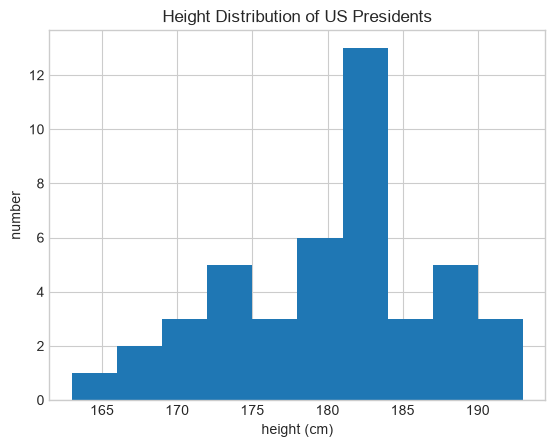

In [61]:
plt.hist(heights)
plt.title('Height Distribution of US Presidents')
plt.xlabel('height (cm)')
plt.ylabel('number');